In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [2]:
import scipy
import tensiometer
# from tensiometer.utilities import stats_utilities as utilities
import tensiometer.utilities as utilities
from tensiometer import mcmc_tension
from tensiometer import gaussian_tension

In [3]:
true_params = np.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

In [4]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

In [5]:
labels_subset = [r"$\Omega_{m}$", r"$\sigma_8$", r"$w_0$"]

# Subset indices from the original labels
subset_indices = [0, 1, 2]  # indices of the first 3 parameters in your labels list
true_params_subset = true_params[0, subset_indices]

def subset_mcsamples(mcsamples, indices):
    # Extract subset of samples corresponding to the desired parameters
    # samples array shape: (num_samples, num_params)
    subset_samples = mcsamples.samples[:, indices]
    subset_labels = [labels[i] for i in indices]
    # Recreate MCSamples object with subsets
    return MCSamples(samples=subset_samples, names=subset_labels, label=mcsamples.label)

### Bin 1

In [5]:
ps_bin1_1024 = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_baryonified_bin1_l30-1024_r20_noisy_s0.26_npe.npy')
ps_bin1_540 = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_baryonified_bin1_l30-540_r20_noisy_s0.26_npe.npy')

In [6]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

ps_bin1_1024 = MCSamples(
    samples=ps_bin1_1024,
    names=labels,
    label="PS bin 1, 1024"
)

ps_bin1_540 = MCSamples(
    samples=ps_bin1_540,
    names=labels,
    label="PS bin 1, 540"
)


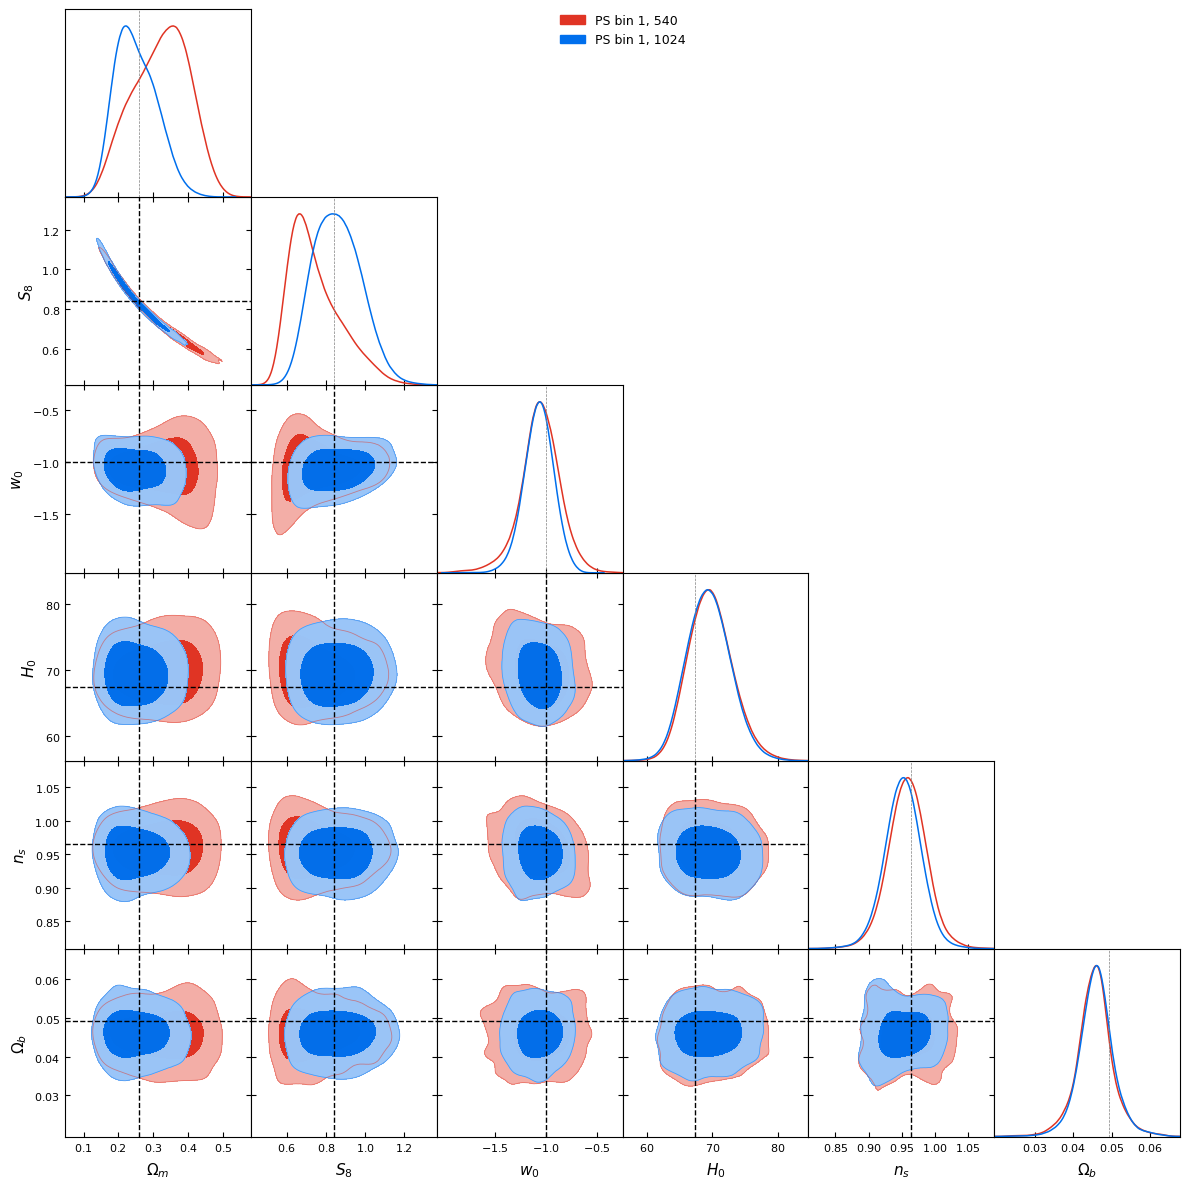

In [ ]:
g = plots.get_subplot_plotter()
g.settings.alpha_filled_add = 0.99

g.triangle_plot([ps_bin1_540, ps_bin1_1024],
                filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )

plt.show()

In [8]:
diff_chain = mcmc_tension.parameter_diff_chain(ps_bin1_1024, ps_bin1_540, boost=4)

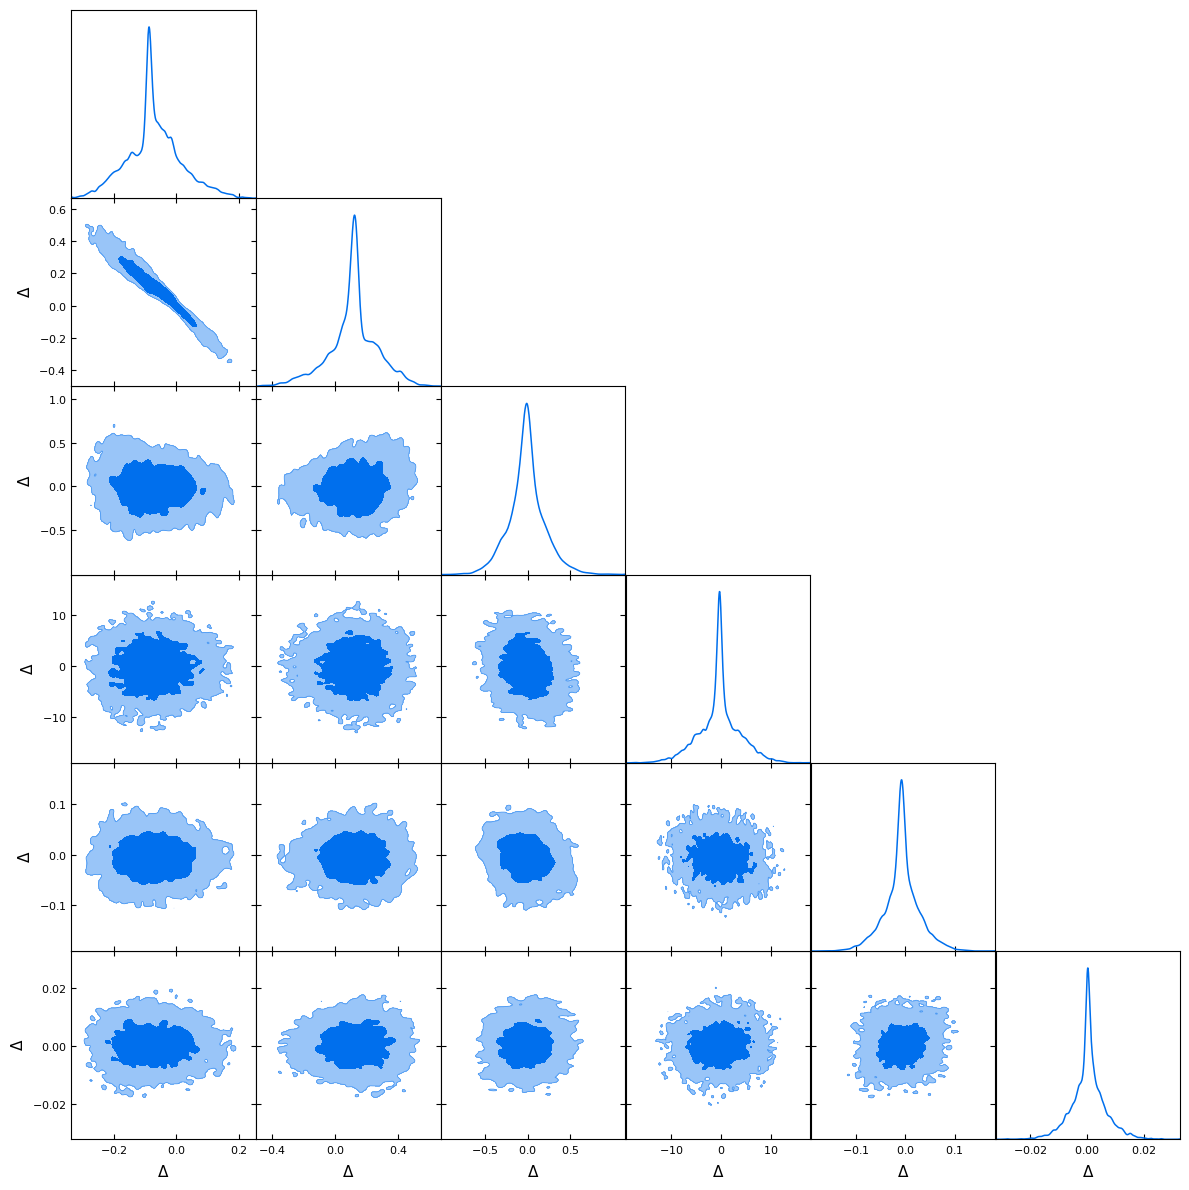

In [10]:
g = plots.get_subplot_plotter()

g.settings.alpha_filled_add = 0.99

g.triangle_plot([diff_chain],
                filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )

plt.show()

In [20]:
Q_DM, Q_DM_dofs = gaussian_tension.Q_DM( ps_bin1_1024, ps_bin1_540 )
Q_DM_P = scipy.stats.chi2.cdf(Q_DM, Q_DM_dofs)
# print everything:
print(f'Q_DM = {Q_DM:.2f}, dofs = {Q_DM_dofs:2}, P = {Q_DM_P:.5f}')
# convert to effective number of sigmas:
Q_DM_nsigma = utilities.from_confidence_to_sigma(Q_DM_P)
# print everything:
print(f'nsigma = {Q_DM_nsigma:.3f}')

Q_DM = 0.64, dofs =  6, P = 0.00430
nsigma = 0.005


### Bin 2

In [27]:
ps_bin2_1024 = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_baryonified_bin2_l30-1024_r20_noisy_s0.26_npe.npy')
ps_bin2_540 = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_baryonified_bin2_l30-540_r20_noisy_s0.26_npe.npy')
# ps_bin2_400 = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_baryonified_bin2_l30-400_r20_noisy_s0.26_npe.npy')

In [28]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

ps_bin2_1024 = MCSamples(
    samples=ps_bin2_1024,
    names=labels,
    label="PS bin 2, 1024"
)

ps_bin2_540 = MCSamples(
    samples=ps_bin2_540,
    names=labels,
    label="PS bin 2, 540"
)

# ps_bin2_400 = MCSamples(
#     samples=ps_bin2_400,
#     names=labels,
#     label="PS bin 2, 400"
# )


Removed no burn in
Removed no burn in


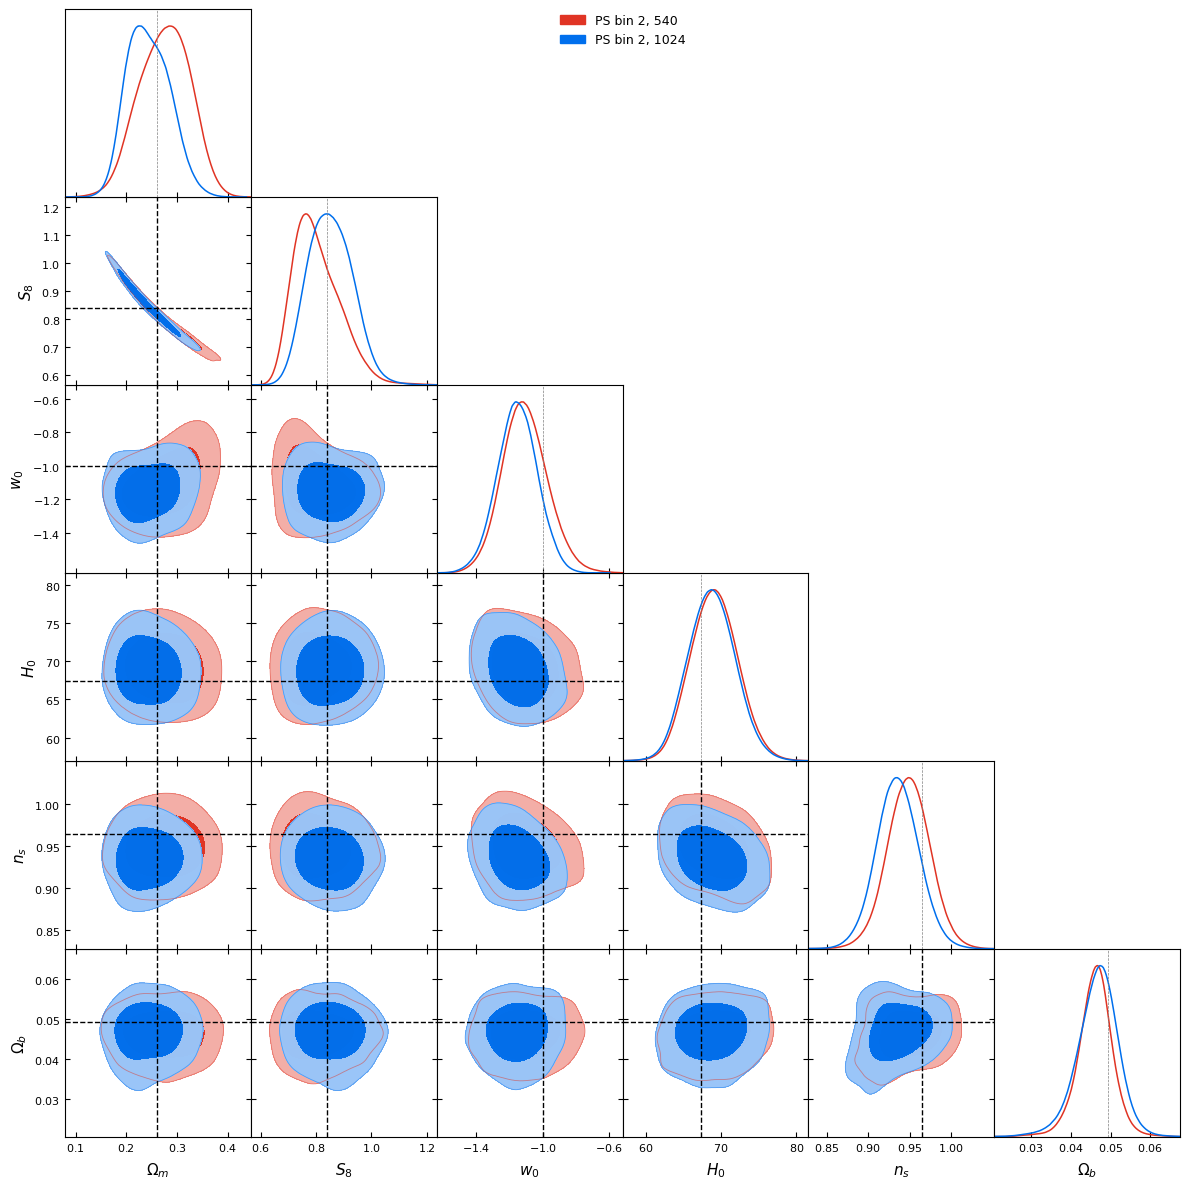

In [29]:
g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([ps_bin2_540, ps_bin2_1024],
                filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )

plt.show()

### Bin 3

In [19]:
ps_bin3_1024 = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_baryonified_bin3_l30-1024_r20_noisy_s0.26_npe.npy')
ps_bin3_540 = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_baryonified_bin3_l30-540_r20_noisy_s0.26_npe.npy')
ps_bin3_400 = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_baryonified_bin3_l30-400_r20_noisy_s0.26_npe.npy')

In [20]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

ps_bin3_1024 = MCSamples(
    samples=ps_bin3_1024,
    names=labels,
    label="PS bin 3, 1024"
)

ps_bin3_540 = MCSamples(
    samples=ps_bin3_540,
    names=labels,
    label="PS bin 3, 540"
)

ps_bin3_400 = MCSamples(
    samples=ps_bin3_400,
    names=labels,
    label="PS bin 3, 400"
)


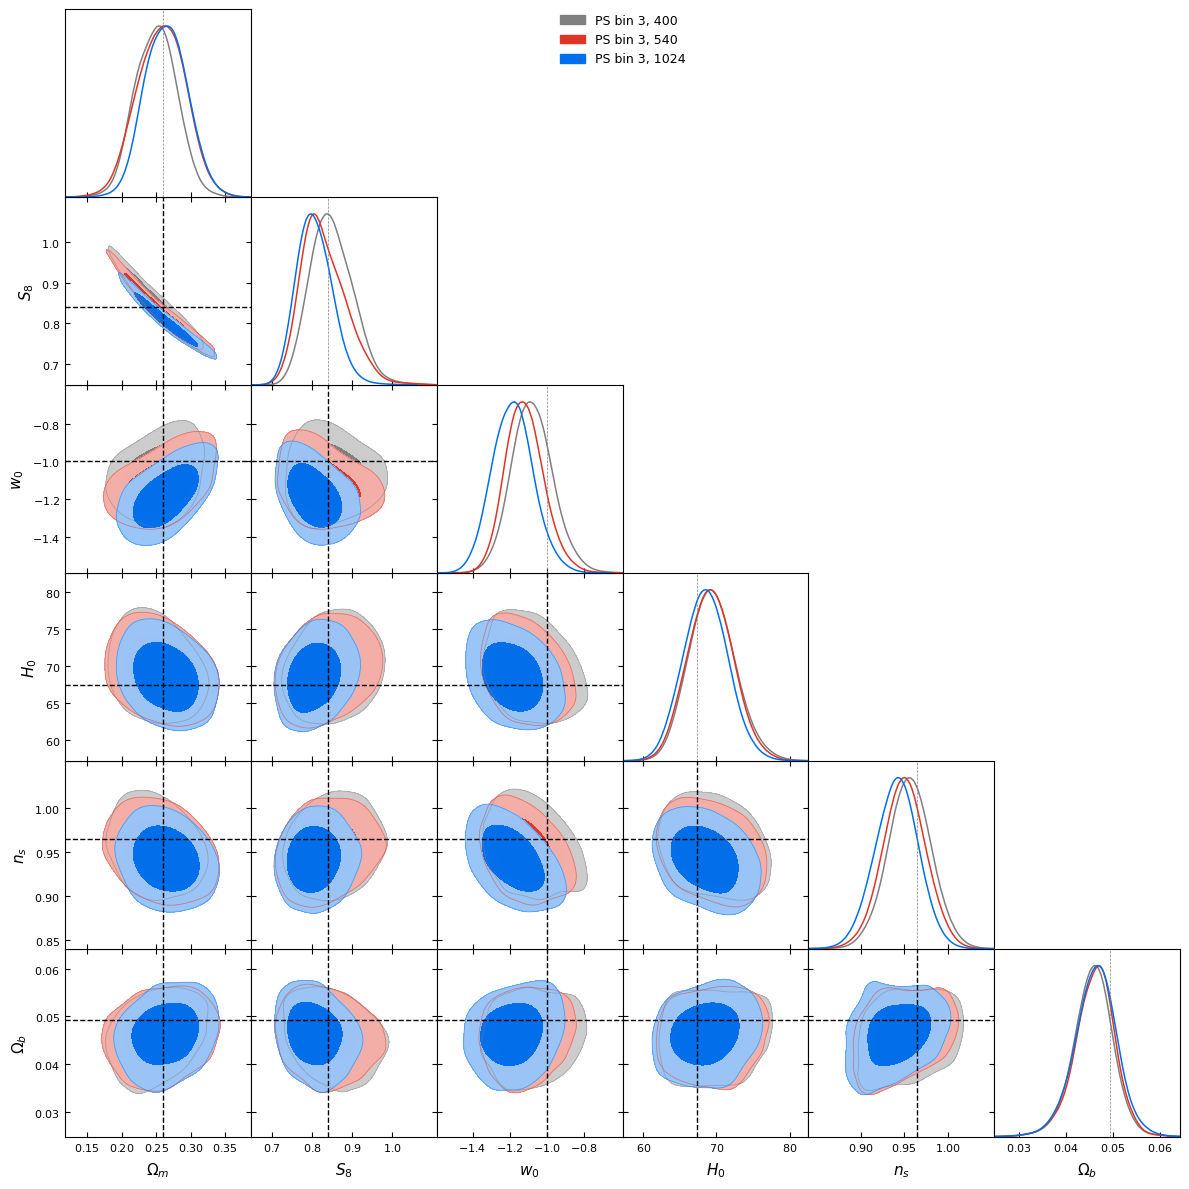

In [38]:
g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([ps_bin3_400, ps_bin3_540, ps_bin3_1024],
                filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )

plt.show()

### Bin 4

In [11]:
ps_bin4_1024 = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_baryonified_bin4_l30-1024_r20_noisy_s0.26_npe.npy')
ps_bin4_540 = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_baryonified_bin4_l30-540_r20_noisy_s0.26_npe.npy')
ps_bin4_400 = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_baryonified_bin4_l30-400_r20_noisy_s0.26_npe.npy')

ps_bin4_1024_unb = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_nobaryons_bin4_l30-1024_r20_noisy_s0.26_npe.npy')
ps_bin4_540_unb = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_nobaryons_bin4_l30-540_r20_noisy_s0.26_npe.npy')

In [12]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

ps_bin4_1024 = MCSamples(
    samples=ps_bin4_1024,
    names=labels,
    label="PS bin 4, 1024"
)

ps_bin4_540 = MCSamples(
    samples=ps_bin4_540,
    names=labels,
    label="PS bin 4, 540"
)

ps_bin4_400 = MCSamples(
    samples=ps_bin4_400,
    names=labels,
    label="PS bin 4, 400"
)


ps_bin4_1024_unb = MCSamples(
    samples=ps_bin4_1024_unb,
    names=labels,
    label="PS bin 4, 1024 unb"
)
ps_bin4_540_unb = MCSamples(
    samples=ps_bin4_540_unb,
    names=labels,
    label="PS bin 4, 540 unb"
)

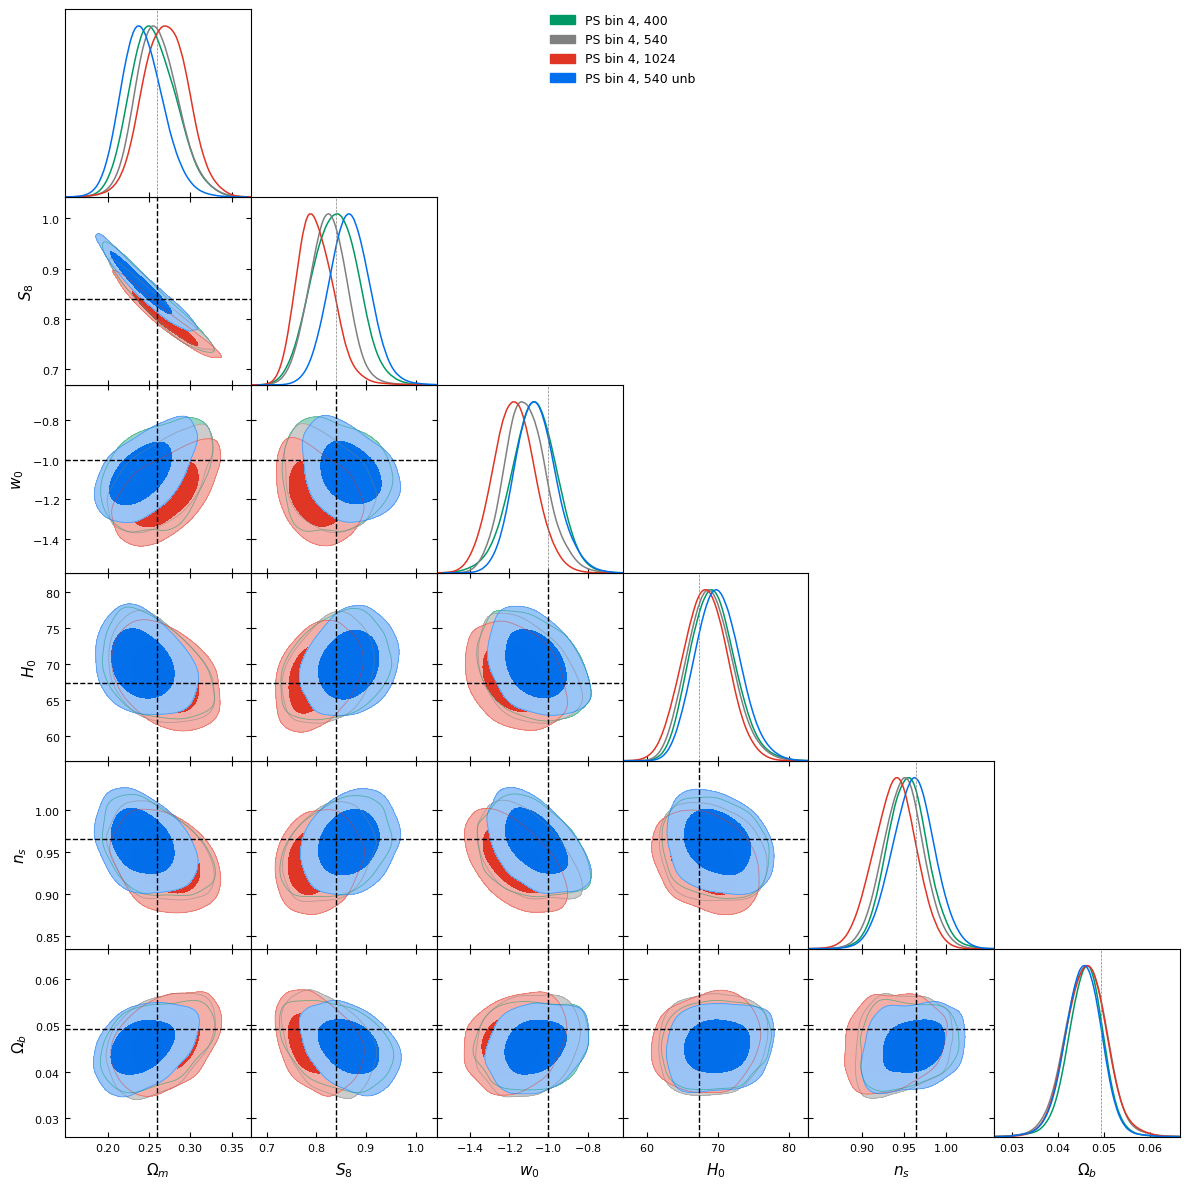

In [32]:
g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([ps_bin4_400, ps_bin4_540, ps_bin4_1024, ps_bin4_540_unb],
                filled=True,    
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )

plt.show()

In [33]:
Q_DM, Q_DM_dofs = gaussian_tension.Q_DM(ps_bin4_540, ps_bin4_540_unb)
Q_DM_P = scipy.stats.chi2.cdf(Q_DM, Q_DM_dofs)
# print everything:
print(f'Q_DM = {Q_DM:.2f}, dofs = {Q_DM_dofs:2}, P = {Q_DM_P:.5f}')
# convert to effective number of sigmas:
Q_DM_nsigma = utilities.from_confidence_to_sigma(Q_DM_P)
# print everything:
print(f'nsigma = {Q_DM_nsigma:.3f}')

Q_DM = 2.21, dofs =  6, P = 0.10024
nsigma = 0.126


## Tomographic

In [27]:
ps_tomo_1024_1024_400_400 = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_baryonified_bins1234_l30-1024-1024-400-400_r20_noisy_s0.26_npe.npy')
ps_tomo_1024_800_600_400 = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_baryonified_bins1234_l30-1024-800-600-400_r20_noisy_s0.26_npe.npy')
ps_tomo_800_800_600_400 = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_baryonified_bins1234_l30-800-800-600-400_r20_noisy_s0.26_npe.npy')
ps_tomo_800_600_500_400 = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_baryonified_bins1234_l30-800-600-500-400_r20_noisy_s0.26_npe.npy')
ps_tomo_490 = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_baryonified_bins1234_l30-490_r20_noisy_s0.26_npe.npy')
ps_tomo_540 = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_baryonified_bins1234_l30-540_r20_noisy_s0.26_npe.npy')
ps_tomo_800 = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_baryonified_bins1234_l30-800_r20_noisy_s0.26_npe.npy')
ps_tomo_500 = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_baryonified_bins1234_l30-500_r20_noisy_s0.26_npe.npy')


ps_tomo_490_unb = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_nobaryons_bins1234_l30-490_r20_noisy_s0.26_npe.npy')
ps_tomo_500_unb = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_nobaryons_bins1234_l30-500_r20_noisy_s0.26_npe.npy')

In [28]:
ps_tomo_1024_1024_400_400 = MCSamples(
    samples=ps_tomo_1024_1024_400_400,
    names=labels,
    label="PS tomo, 1024-1024-400-400"
)
ps_tomo_1024_800_600_400 = MCSamples(
    samples=ps_tomo_1024_800_600_400,
    names=labels,
    label="PS tomo, 1024-800-600-400"
)
ps_tomo_800_800_600_400 = MCSamples(
    samples=ps_tomo_800_800_600_400,
    names=labels,
    label="PS tomo, 800-800-600-400"
)
ps_tomo_800_600_500_400 = MCSamples(
    samples=ps_tomo_800_600_500_400,
    names=labels,
    label="PS tomo, 800-600-500-400"
)
ps_tomo_490 = MCSamples(
    samples=ps_tomo_490,
    names=labels,
    label="PS tomo, 490"
)
ps_tomo_540 = MCSamples(
    samples=ps_tomo_540,
    names=labels,
    label="PS tomo, 540"
) 
ps_tomo_800 = MCSamples(
    samples=ps_tomo_800,
    names=labels,
    label="PS tomo, 800"
)
ps_tomo_500 = MCSamples(
    samples=ps_tomo_500,
    names=labels,
    label="PS tomo, 500"
)

ps_tomo_490_unb = MCSamples(
    samples=ps_tomo_490_unb,
    names=labels,
    label="PS tomo, 490 unb"
)
ps_tomo_500_unb = MCSamples(
    samples=ps_tomo_500_unb,
    names=labels,
    label="PS tomo, 500 unb"
)

In [17]:
# Create subsets
ps_tomo_490_unb_sub = subset_mcsamples(ps_tomo_490_unb, subset_indices)
ps_tomo_490_sub = subset_mcsamples(ps_tomo_490, subset_indices)

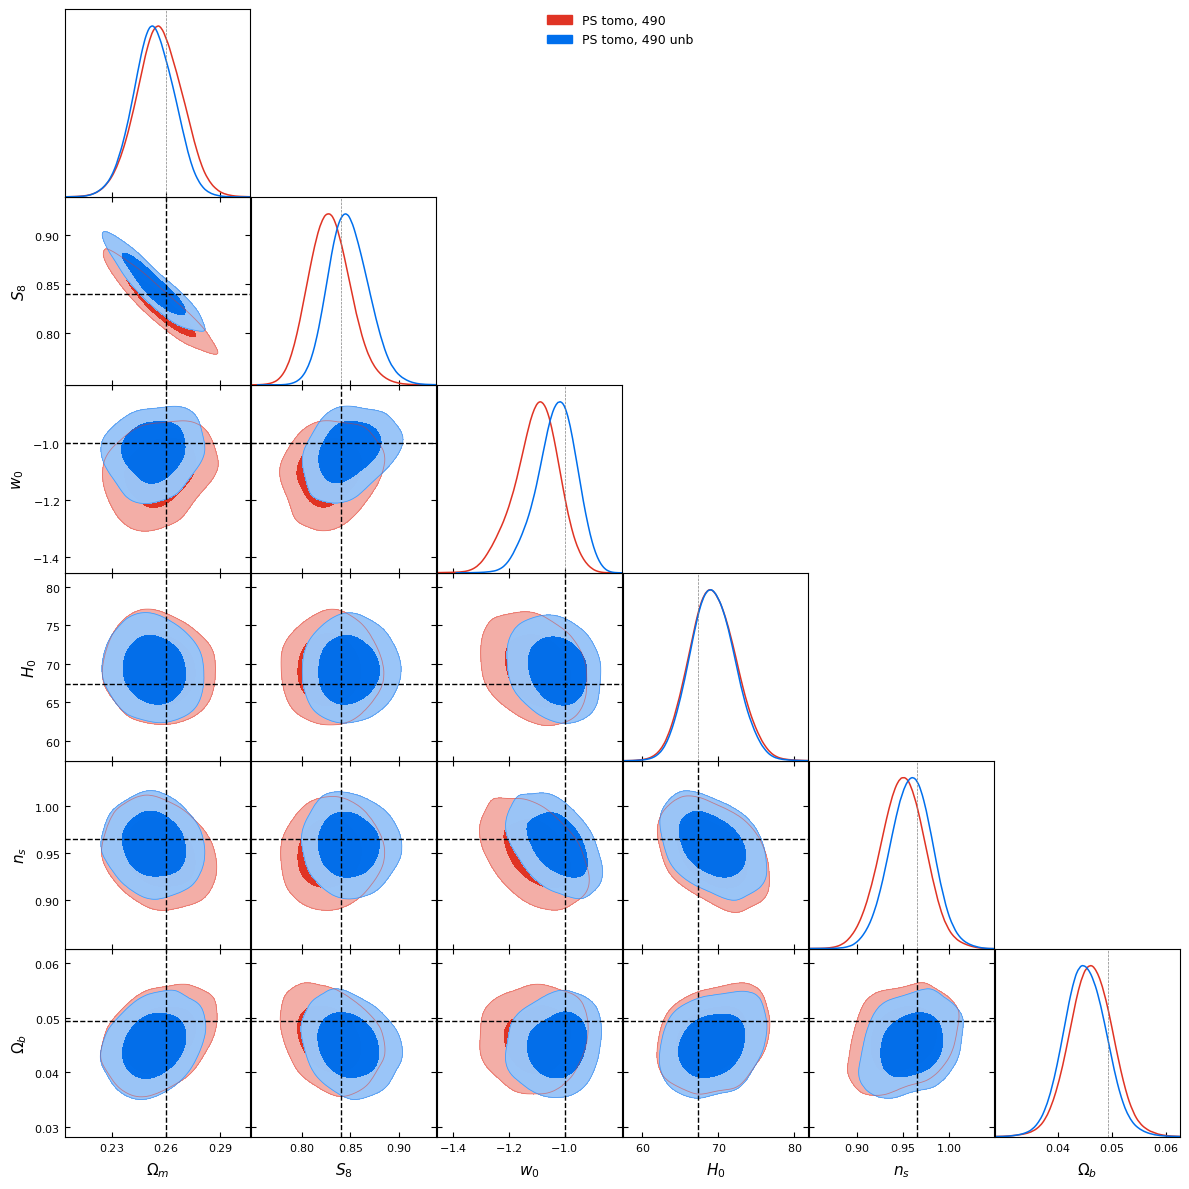

In [13]:
g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([ps_tomo_490, ps_tomo_490_unb],
                filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )

plt.show()

In [18]:
Q_DM, Q_DM_dofs = gaussian_tension.Q_DM(ps_tomo_490_sub, ps_tomo_490_unb_sub)
Q_DM_P = scipy.stats.chi2.cdf(Q_DM, Q_DM_dofs)
# print everything:
print(f'Q_DM = {Q_DM:.2f}, dofs = {Q_DM_dofs:2}, P = {Q_DM_P:.5f}')
# convert to effective number of sigmas:
Q_DM_nsigma = utilities.from_confidence_to_sigma(Q_DM_P)
# print everything:
print(f'nsigma = {Q_DM_nsigma:.3f}')

Q_DM = 3.95, dofs =  3, P = 0.73273
nsigma = 1.109


# Masked

### Bin 4

In [7]:
ps_bin4_1024_masked = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_baryonified_bin4_l30-1024_r20_masked_14300sqdeg_noisy_s0.26_npe.npy')

ps_bin4_1024_unb_masked = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_nobaryons_bin4_l30-1024_r20_masked_14300sqdeg_noisy_s0.26_npe.npy')

In [8]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

ps_bin4_1024_masked = MCSamples(
    samples=ps_bin4_1024_masked,
    names=labels,
    label="PS bin 4, 1024 masked"
)

ps_bin4_1024_unb_masked = MCSamples(
    samples=ps_bin4_1024_unb_masked,
    names=labels,
    label="PS bin 4, 1024 unb masked"
)

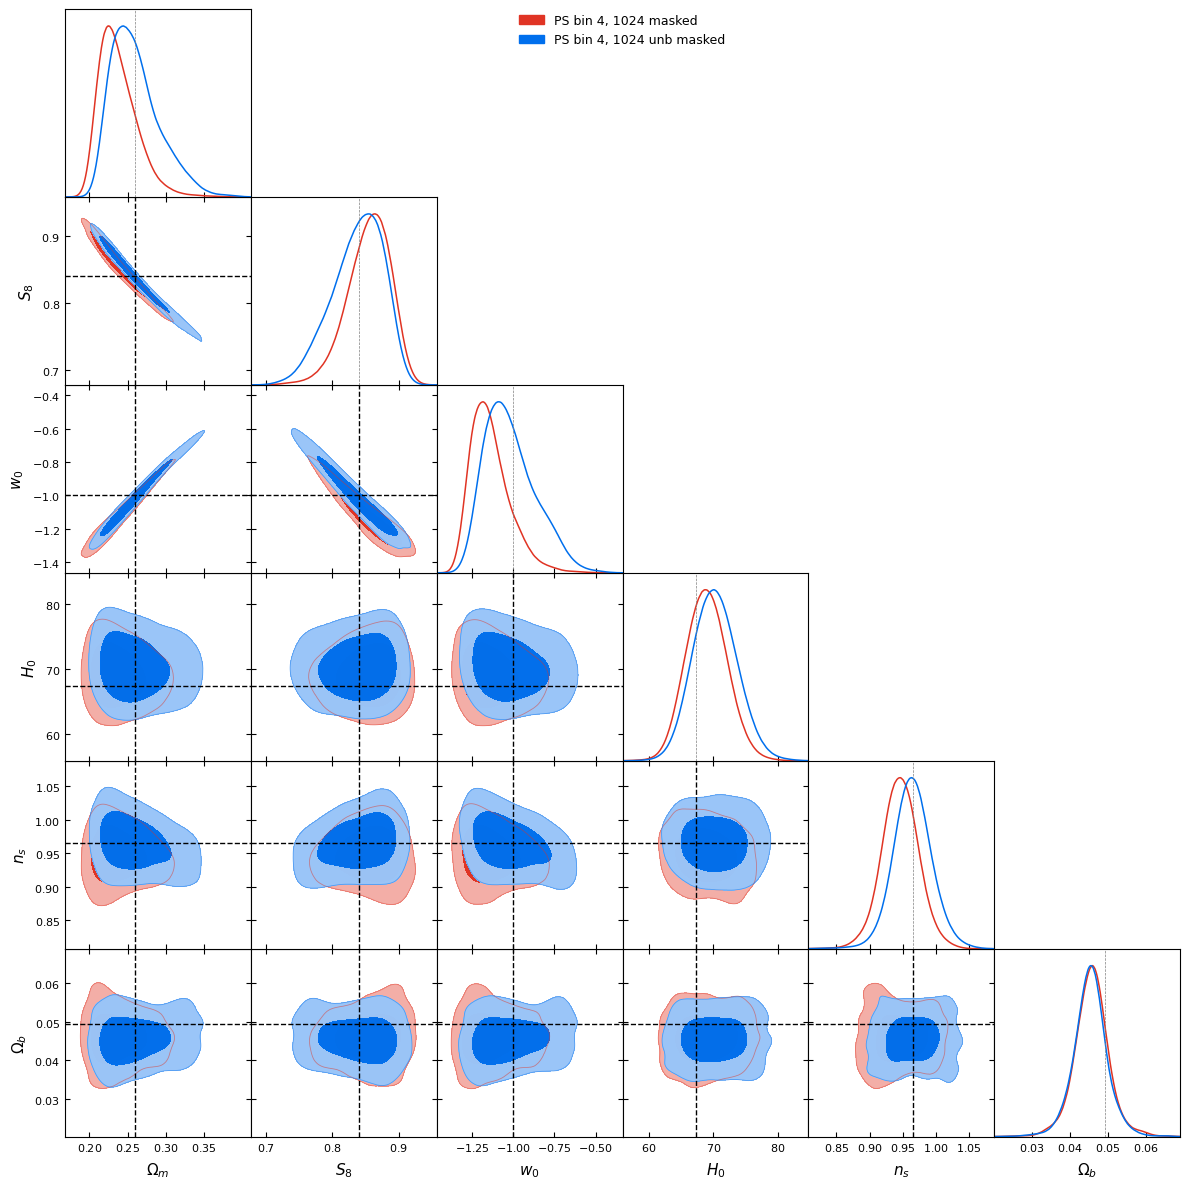

In [9]:
g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([ps_bin4_1024_masked, ps_bin4_1024_unb_masked],
                filled=True,    
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )

plt.show()

In [10]:
Q_DM, Q_DM_dofs = gaussian_tension.Q_DM(ps_bin4_1024_masked, ps_bin4_1024_unb_masked)
Q_DM_P = scipy.stats.chi2.cdf(Q_DM, Q_DM_dofs)
# print everything:
print(f'Q_DM = {Q_DM:.2f}, dofs = {Q_DM_dofs:2}, P = {Q_DM_P:.5f}')
# convert to effective number of sigmas:
Q_DM_nsigma = utilities.from_confidence_to_sigma(Q_DM_P)
# print everything:
print(f'nsigma = {Q_DM_nsigma:.3f}')

Q_DM = 4.47, dofs =  6, P = 0.38607
nsigma = 0.504


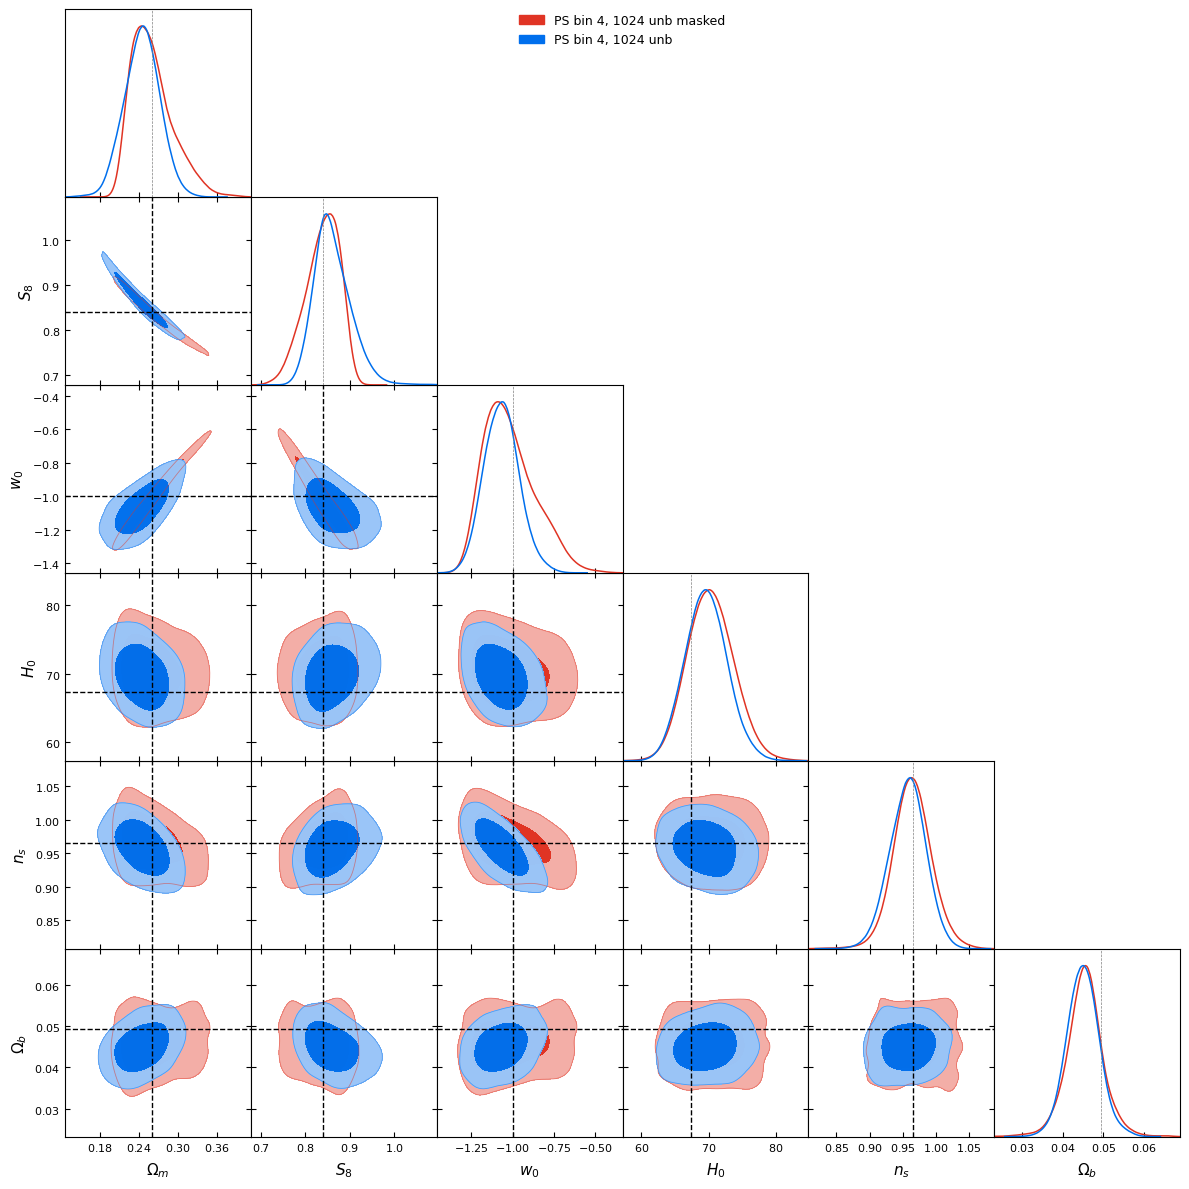

In [13]:
g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([ps_bin4_1024_unb_masked, ps_bin4_1024_unb],
                filled=True,    
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )

plt.show()

### Bin 3

In [14]:
ps_bin3_1024_masked = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_baryonified_bin3_l30-1024_r20_masked_14300sqdeg_noisy_s0.26_npe.npy')

ps_bin3_1024_unb_masked = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_nobaryons_bin3_l30-1024_r20_masked_14300sqdeg_noisy_s0.26_npe.npy')

In [15]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

ps_bin3_1024_masked = MCSamples(
    samples=ps_bin3_1024_masked,
    names=labels,
    label="PS bin 3, 1024 masked"
)

ps_bin3_1024_unb_masked = MCSamples(
    samples=ps_bin3_1024_unb_masked,
    names=labels,
    label="PS bin 3, 1024 unb masked"
)

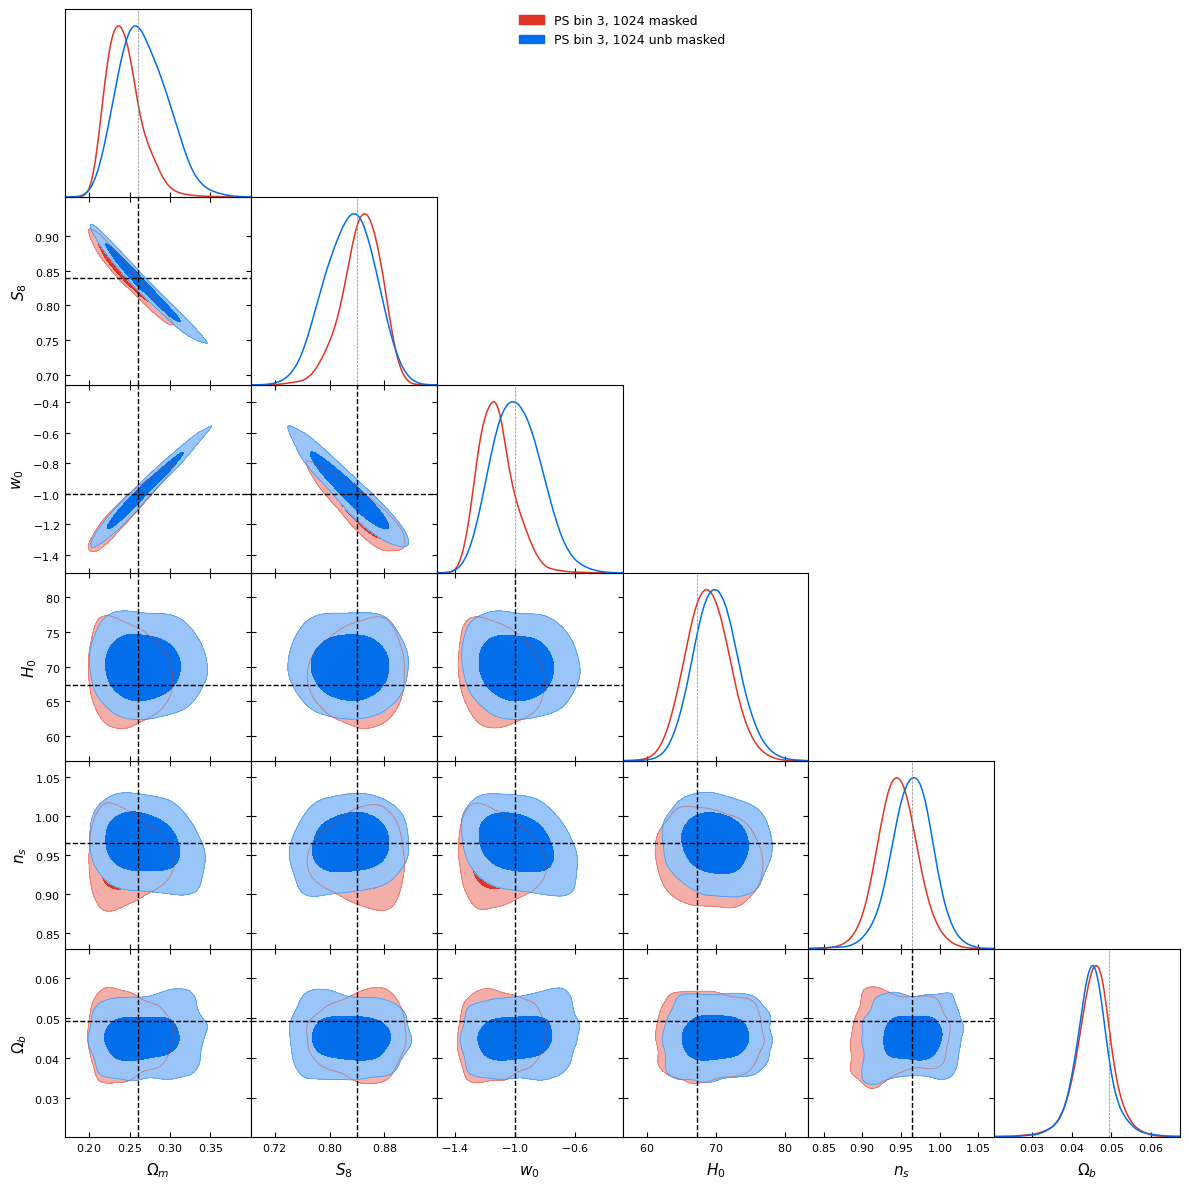

In [16]:
g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([ps_bin3_1024_masked, ps_bin3_1024_unb_masked],
                filled=True,    
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )

plt.show()

In [18]:
Q_DM, Q_DM_dofs = gaussian_tension.Q_DM(ps_bin3_1024_masked, ps_bin3_1024_unb_masked)
Q_DM_P = scipy.stats.chi2.cdf(Q_DM, Q_DM_dofs)
# print everything:
print(f'Q_DM = {Q_DM:.2f}, dofs = {Q_DM_dofs:2}, P = {Q_DM_P:.5f}')
# convert to effective number of sigmas:
Q_DM_nsigma = utilities.from_confidence_to_sigma(Q_DM_P)
# print everything:
print(f'nsigma = {Q_DM_nsigma:.3f}')

Q_DM = 4.52, dofs =  6, P = 0.39323
nsigma = 0.515


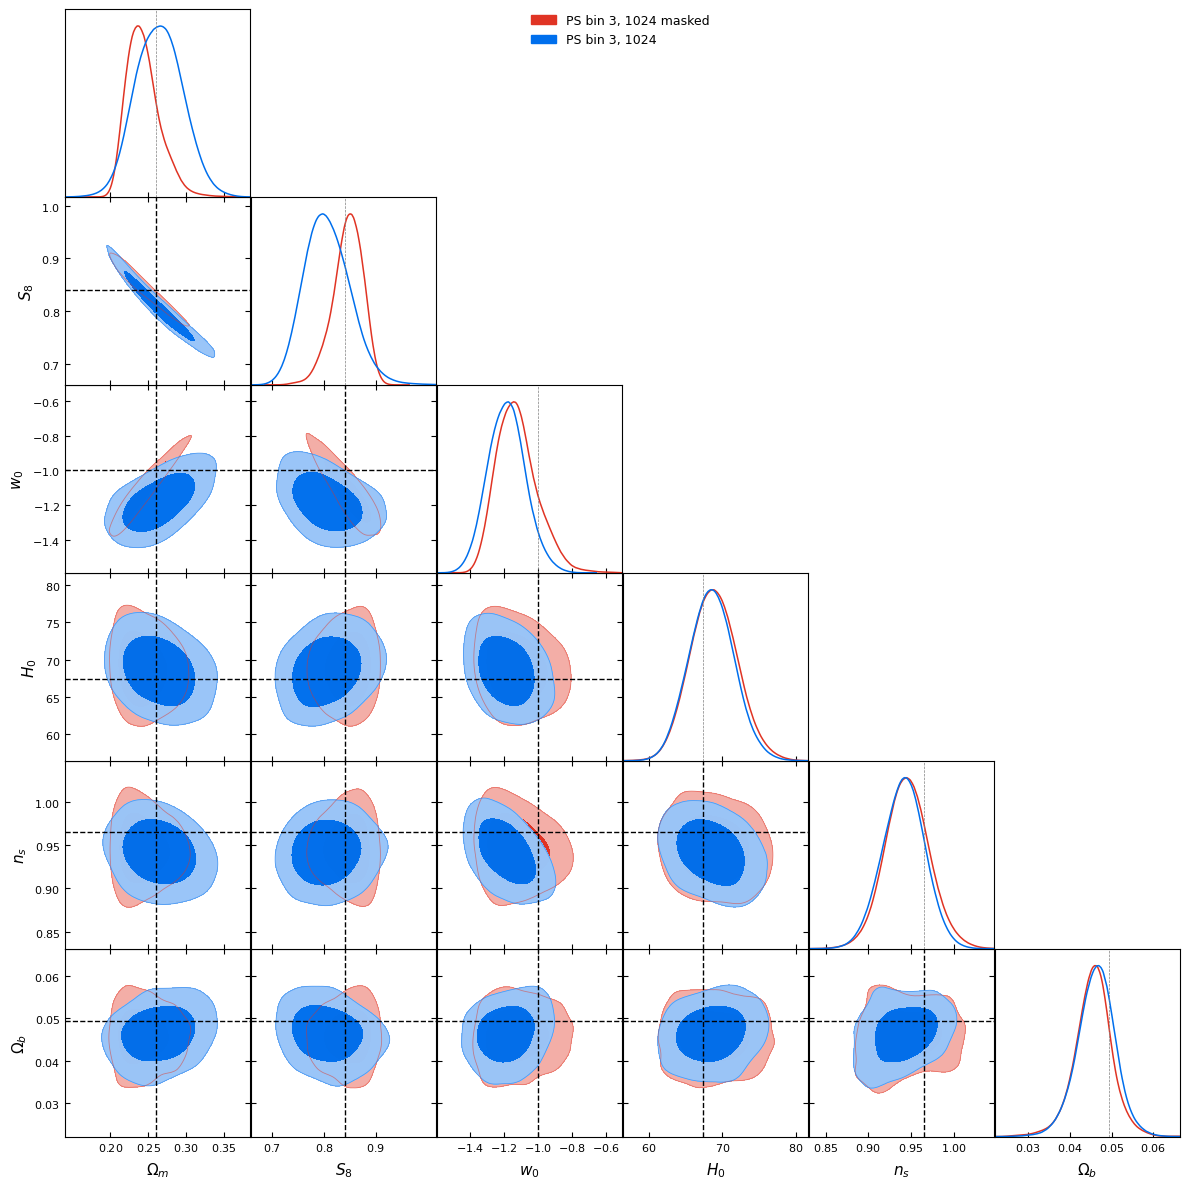

In [22]:
g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([ps_bin3_1024_masked, ps_bin3_1024],
                filled=True,    
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )

plt.show()

## Tomographic

In [39]:
ps_tomo_1024_masked_unb = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_nobaryons_bins1234_l30-1024_r20_masked_14300sqdeg_noisy_s0.26_npe.npy')
ps_tomo_600_masked_unb = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_nobaryons_bins1234_l30-600_r20_masked_14300sqdeg_noisy_s0.26_npe.npy')
ps_tomo_540_masked_unb = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_nobaryons_bins1234_l30-540_r20_masked_14300sqdeg_noisy_s0.26_npe.npy')

ps_tomo_1024_masked = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_baryonified_bins1234_l30-1024_r20_masked_14300sqdeg_noisy_s0.26_npe.npy')
ps_tomo_600_masked = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_baryonified_bins1234_l30-600_r20_masked_14300sqdeg_noisy_s0.26_npe.npy')
ps_tomo_540_masked = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_baryonified_bins1234_l30-540_r20_masked_14300sqdeg_noisy_s0.26_npe.npy')

In [40]:
ps_tomo_1024_masked_unb = MCSamples(
    samples=ps_tomo_1024_masked_unb,
    names=labels,
    label="PS tomo, 1024 masked unb"
)
ps_tomo_600_masked_unb = MCSamples(
    samples=ps_tomo_600_masked_unb,
    names=labels,
    label="PS tomo, 600 masked unb"
)
ps_tomo_540_masked_unb = MCSamples(
    samples=ps_tomo_540_masked_unb,
    names=labels,
    label="PS tomo, 540 masked unb"
)

ps_tomo_1024_masked = MCSamples(
    samples=ps_tomo_1024_masked,
    names=labels,
    label="PS tomo, 1024 masked"
)
ps_tomo_600_masked = MCSamples(
    samples=ps_tomo_600_masked,
    names=labels,
    label="PS tomo, 600 masked"
)
ps_tomo_540_masked = MCSamples(
    samples=ps_tomo_540_masked,
    names=labels,
    label="PS tomo, 540 masked"
)

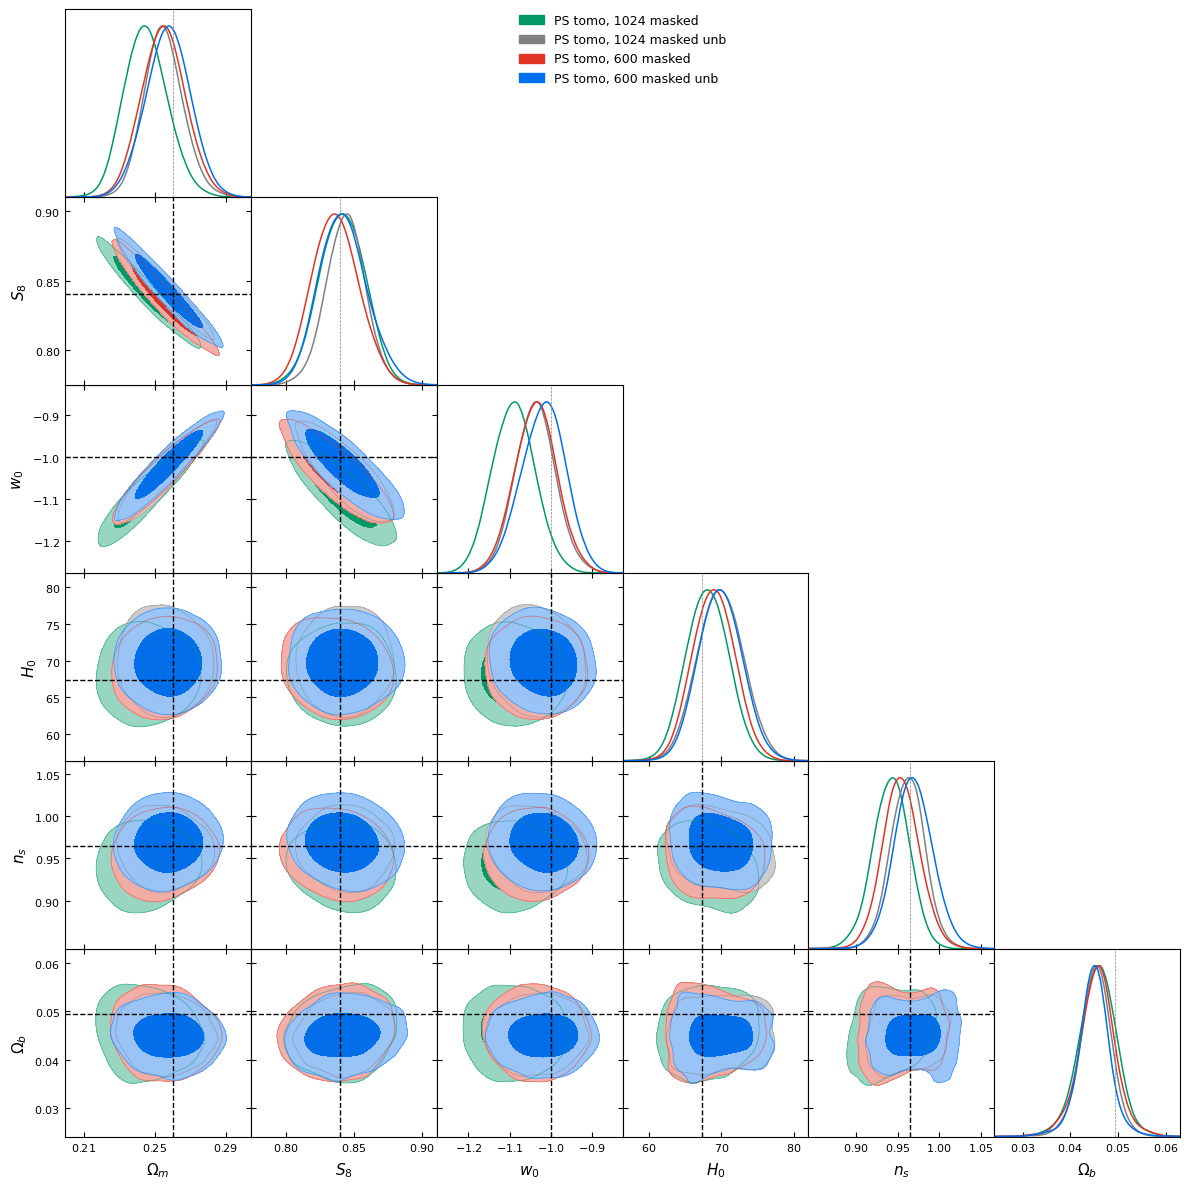

In [41]:
g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([ps_tomo_1024_masked, ps_tomo_1024_masked_unb, ps_tomo_600_masked, ps_tomo_600_masked_unb],
                filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )

plt.show()

In [42]:
Q_DM, Q_DM_dofs = gaussian_tension.Q_DM(ps_tomo_600_masked, ps_tomo_600_masked_unb)
Q_DM_P = scipy.stats.chi2.cdf(Q_DM, Q_DM_dofs)
# print everything:
print(f'Q_DM = {Q_DM:.2f}, dofs = {Q_DM_dofs:2}, P = {Q_DM_P:.5f}')
# convert to effective number of sigmas:
Q_DM_nsigma = utilities.from_confidence_to_sigma(Q_DM_P)
# print everything:
print(f'nsigma = {Q_DM_nsigma:.3f}')

Q_DM = 2.77, dofs =  6, P = 0.16252
nsigma = 0.205


# BNT tomo vs noBNT Bin 1

In [21]:
ps_bin4_1024 = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_baryonified_bin3_l30-1024_r20_noisy_s0.26_npe.npy')
PS_auto_bar_bnt = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_baryonified_bntbins1234_l30-1024_r20_noisy_s0.26_npe.npy')
PS_auto_nobar = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_nobaryons_bins1234_l30-1024_r10_noisy_s0.26_npe.npy')

In [22]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

ps_bin4_1024 = MCSamples(
    samples=ps_bin4_1024,
    names=labels,
    label="PS bin 4, 1024"
)

PS_auto_bar_bnt = MCSamples(
    samples=PS_auto_bar_bnt,
    names=labels,
    label="PS auto bar BNT"
)
PS_auto_nobar = MCSamples(
    samples=PS_auto_nobar,
    names=labels,
    label="PS auto no bar"
)


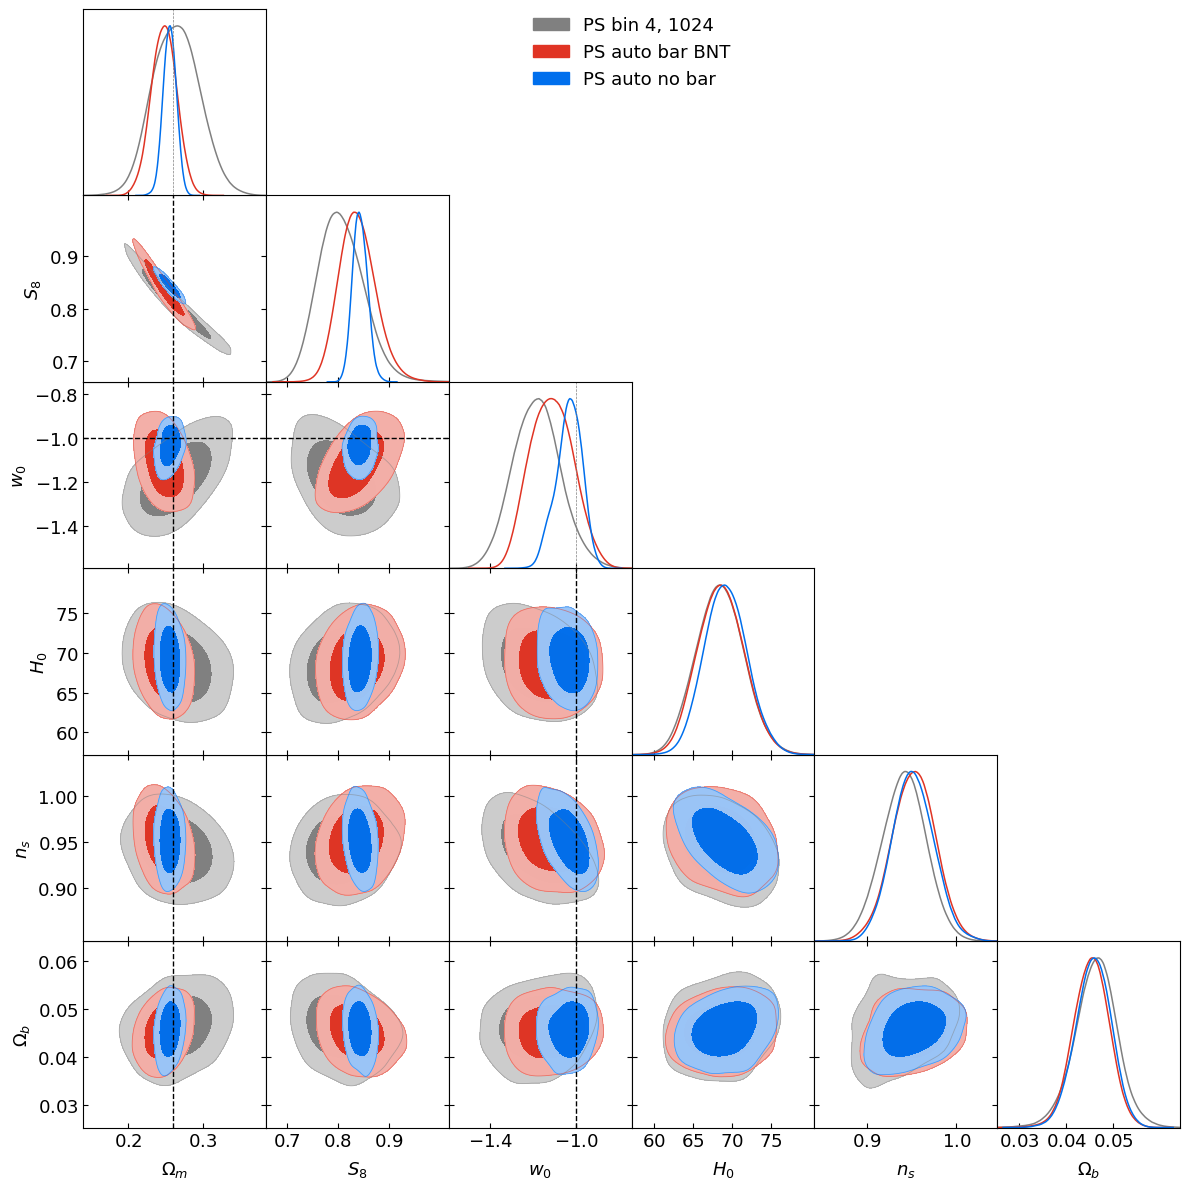

In [23]:
g = plots.get_subplot_plotter()
g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99  

g.settings.legend_fontsize = 16 
g.settings.axes_fontsize = 16
g.settings.lab_fontsize = 16

g.triangle_plot([ps_bin4_1024, PS_auto_bar_bnt, PS_auto_nobar], 
                filled=True,
                markers={label: val for label, val in zip(labels_subset, true_params_subset)},
                contour_lws=1.1,
                marker_args={'color': 'black', 'lw': 1.}
               )

plt.show()